# Bird Call Classification Using Convolutional Neural Networks
# Student Name - Gurpreet Kaur
## DATA 5322 - Homework 3

In this notebook, convolutional neural networks (CNNs) are used to classify bird calls from 12 bird species commonly found in the Seattle area. The audio recordings are represented as mel spectrograms, which allow the model to learn frequency and timing patterns from the sounds.

The project includes both a binary classification task and a multiclass classification task. First, a model is trained to distinguish between two bird species. Then, the approach is expanded to classify all 12 species. Finally, the trained model is tested on three unlabeled audio recordings to evaluate how well it performs on unseen data.

Full theoretical background and methodology are provided
in the accompanying written report. This notebook focuses on
implementation, results, and observations.

## Libraries

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import librosa
import time
import seaborn as sns
from PIL import Image
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Loading and Exploration

The dataset used in this project comes from Xeno-Canto [2], a crowd-sourced archive of bird sound recordings collected from contributors around the world. The sound clip is subsampled to 22050 Hz and dataset contains an uneven number of samples per species ranging from 37 to 630, resulting in 1,981 total samples. Audio recordings were converted into mel spectrograms to prepare them for machine learning analysis. Spectrograms represent sound as a two-dimensional image showing frequency changes over time, making them well suited for image-based deep learning methods such as convolutional neural networks.

In this section, Google Drive is mounted so the dataset can be accessed. After loading the data, a sample spectrogram from each species is displayed to better understand the structure and visual differences between bird calls.

In [3]:
f = h5py.File('/content/drive/MyDrive/Homework3/bird_spectrograms.hdf5', 'r')
species = list(f.keys())
print("Bird species:", species)

for s in species:
    print(f"{s}: {f[s].shape[0]} samples, shape: {f[s].shape[1:]}")

Bird species: ['amecro', 'amerob', 'bewwre', 'bkcchi', 'daejun', 'houfin', 'houspa', 'norfli', 'rewbla', 'sonspa', 'spotow', 'whcspa']
amecro: 128 samples, shape: (517, 66)
amerob: 128 samples, shape: (517, 172)
bewwre: 128 samples, shape: (517, 144)
bkcchi: 128 samples, shape: (517, 45)
daejun: 128 samples, shape: (517, 125)
houfin: 128 samples, shape: (517, 84)
houspa: 128 samples, shape: (517, 630)
norfli: 128 samples, shape: (517, 37)
rewbla: 128 samples, shape: (517, 187)
sonspa: 128 samples, shape: (517, 263)
spotow: 128 samples, shape: (517, 137)
whcspa: 128 samples, shape: (517, 91)


Each bird species has 128 samples. The spectrogram data has the same number of rows (517) for all species, but the number of features (columns) is different for each one. This shows that different bird calls have different levels of frequency patterns and complexity.

In [4]:
#I will look at the exact structure to make sure data is split rightly
for s in species[:3]:
  data=f[s]
  print(f"{s}: shape = {data.shape}")
  print(f"  If dim 0 = samples: {data.shape[0]} samples")
  print(f"  If dim 2 = samples: {data.shape[2]} samples")

amecro: shape = (128, 517, 66)
  If dim 0 = samples: 128 samples
  If dim 2 = samples: 66 samples
amerob: shape = (128, 517, 172)
  If dim 0 = samples: 128 samples
  If dim 2 = samples: 172 samples
bewwre: shape = (128, 517, 144)
  If dim 0 = samples: 128 samples
  If dim 2 = samples: 144 samples


So each bird has same 128 recording and the 517 is same for the checked species. So this is 3D data.

### Standardize data and look at shape

Lets add target frequency to 128 and target time to 517 to standardize the data.

In [5]:
from  PIL import Image

TARGET_FREQ = 128
TARGET_TIME = 517

def load_and_resize (f, species):
  X, y = [], []
  for label, s in enumerate(species):
    data = f[s][:]  # shape (128, 517, N_samples)
    n_samples = data.shape[2]
    print(f"{s}: {n_samples} samples")
    for i in range(n_samples):
      sample = data[:, :, i]

      img = Image.fromarray(sample.astype(np.float32))
      img_resized = img.resize((TARGET_TIME, TARGET_FREQ))
      arr = np.array(img_resized, dtype=np.float32)
      X.append(arr)
      y.append(label)
  return np.array(X), np.array(y)

X, y = load_and_resize(f, species)
print(f"\nX shape: {X.shape}")
print(f"Total samples: {len(y)}")
print(f"Unique labels: {np.unique(y)}")

amecro: 66 samples
amerob: 172 samples
bewwre: 144 samples
bkcchi: 45 samples
daejun: 125 samples
houfin: 84 samples
houspa: 630 samples
norfli: 37 samples
rewbla: 187 samples
sonspa: 263 samples
spotow: 137 samples
whcspa: 91 samples

X shape: (1981, 128, 517)
Total samples: 1981
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]


So each bird has different number of recordings. The shape of the dataset is (1981,128,517) meaning we have 1981 recording from 128 frequency and 517 time stamps. The total number of birds are 12 from 0 to 11.

### Visualise the data

Lets look at the spectogram for each bird species.

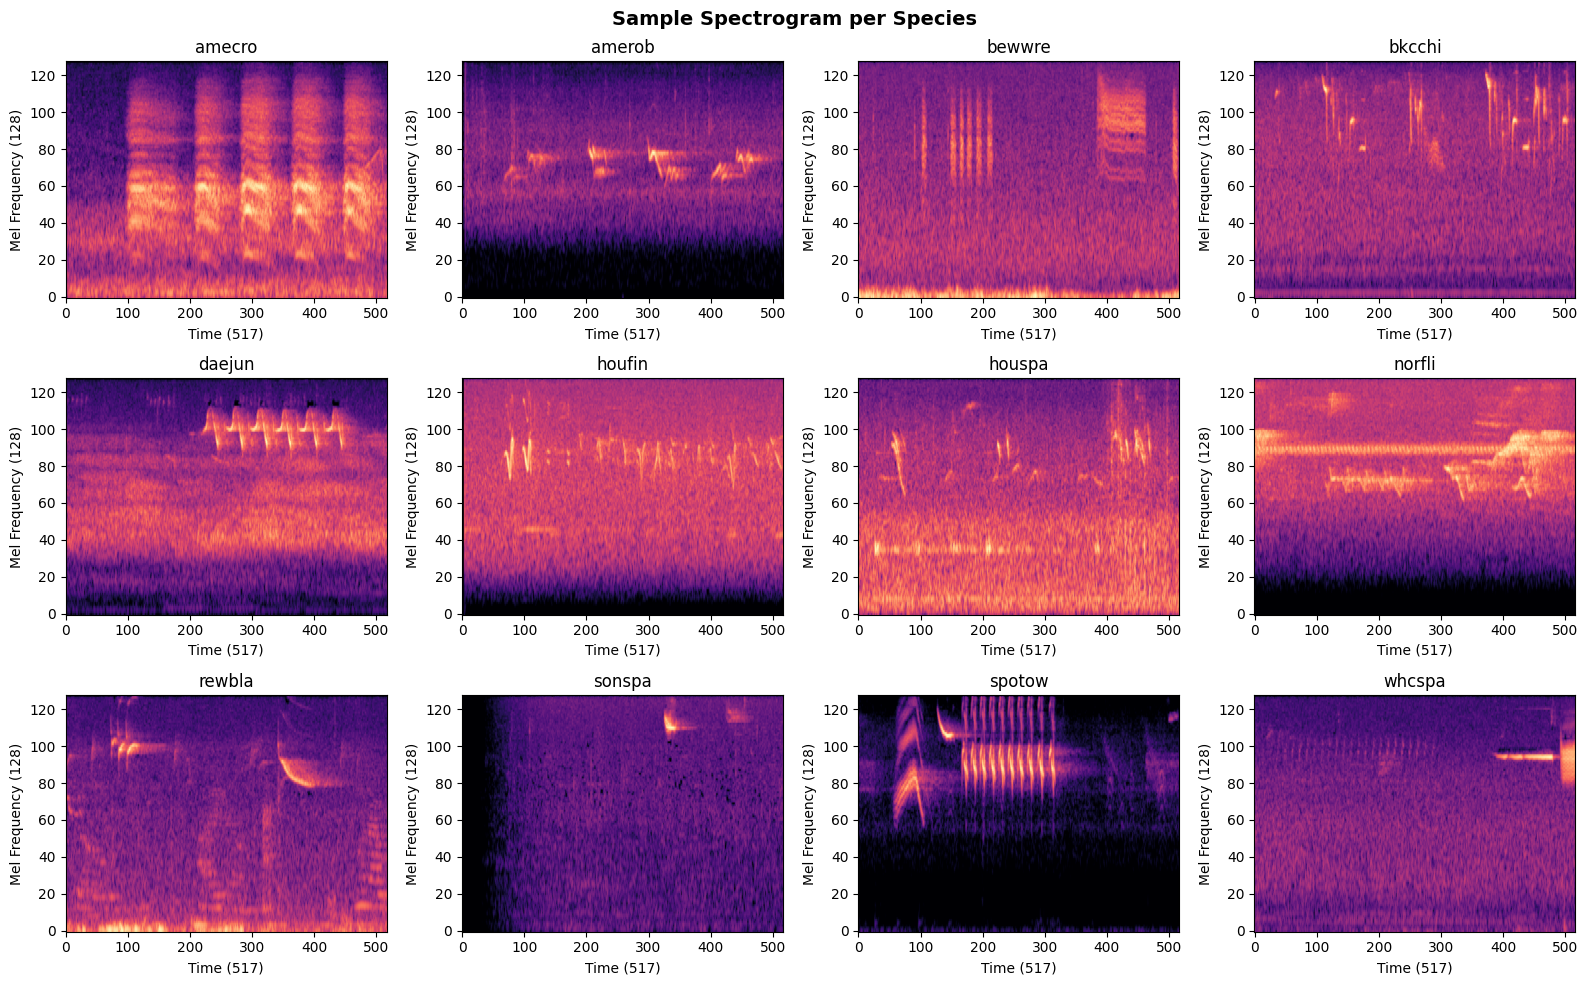

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i,s in enumerate(species):
  sample = f[s][:,:,0] #correct: (128, 517)
  axes[i].imshow(sample, aspect='auto', origin='lower', cmap='magma')
  axes[i].set_title(s, fontsize=12)
  axes[i].set_xlabel('Time (517)')
  axes[i].set_ylabel('Mel Frequency (128)')

plt.suptitle('Sample Spectrogram per Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The spectograms now look far better than before. Clear differences in frequency distribution and pattern density are visible across species.

## Data Preprocessing

Before training the neural network, all spectrograms are resized to a consistent shape of (128,517) using the PIL resize function. The pixel values are normalized to the range [0, 1] to improve training stability.

Since CNNs expect image-like inputs, a channel dimension is added to each spectrogram. The dataset is then split into training and testing sets using an 80/20 ratio while preserving class balance through stratified sampling.

Finally, PyTorch DataLoaders are created with a batch size of 32 to efficiently feed data into the model during training.

### Normalize and Test/Train the data

In [7]:
# Normalize
X = (X - X.min()) / (X.max() - X.min())

# Add channel dimension
X = X[:, np.newaxis, :, :]
print(f"X shape after channel: {X.shape}")

# Train/test split - stratified to handle uneven classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Label dtype: {y_train_t.dtype}")

X shape after channel: (1981, 1, 128, 517)
Training samples: 1584
Test samples: 397
Label dtype: torch.int64


Lets check for labels are correct and that each bird species is properly balanced and split into training and test datasets without mistakes.

In [8]:
print("Label verification:")
print(f"Label dtype: {y_train_t.dtype}")
print(f"Correct dtype: {y_train_t.dtype == torch.int64}")
print("\nSpecies mapping and sample counts:")
for i, s in enumerate(species):
    total = np.sum(y == i)
    train_count = np.sum(y_train == i)
    test_count  = np.sum(y_test == i)
    print(f"  {i}: {s} — total: {total}, train: {train_count}, test: {test_count}")

Label verification:
Label dtype: torch.int64
Correct dtype: True

Species mapping and sample counts:
  0: amecro — total: 66, train: 53, test: 13
  1: amerob — total: 172, train: 137, test: 35
  2: bewwre — total: 144, train: 115, test: 29
  3: bkcchi — total: 45, train: 36, test: 9
  4: daejun — total: 125, train: 100, test: 25
  5: houfin — total: 84, train: 67, test: 17
  6: houspa — total: 630, train: 504, test: 126
  7: norfli — total: 37, train: 30, test: 7
  8: rewbla — total: 187, train: 149, test: 38
  9: sonspa — total: 263, train: 210, test: 53
  10: spotow — total: 137, train: 110, test: 27
  11: whcspa — total: 91, train: 73, test: 18


The datset looks correct, each species has different number of recordings, The above output confirms the dataset is correctly labeled and properly split for model evaluation.

## Binary Classification: American Crow vs American Robin

The first experiment focuses on distinguishing between two bird species: the American Crow (amecro) and the American Robin (amerob). These species were selected because their vocalizations are noticeably different, making them a useful starting point for evaluating the CNN architecture.

Several model configurations are tested by changing the learning rate and network depth. Comparing these models helps determine how architectural choices affect classification performance and training efficiency.

In [14]:
# Binary data preparation and class weights
from sklearn.utils.class_weight import compute_class_weight

binary_species = ['amecro', 'amerob']
binary_idx = [species.index(s) for s in binary_species]

mask = np.isin(y, binary_idx)
X_bin = X[mask]
y_bin = (y[mask] == binary_idx[1]).astype(int)

print(f"Binary dataset size: {X_bin.shape}")
print(f"Class counts: amecro={np.sum(y_bin==0)}, amerob={np.sum(y_bin==1)}")

X_bin_train, X_bin_test, y_bin_train, y_bin_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

print(f"Train: amecro={np.sum(y_bin_train==0)}, amerob={np.sum(y_bin_train==1)}")
print(f"Test:  amecro={np.sum(y_bin_test==0)}, amerob={np.sum(y_bin_test==1)}")

# Compute class weights
bin_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_bin_train
)
pos_weight = bin_weights[0] / bin_weights[1]
print(f"\nClass weights: amecro={bin_weights[0]:.4f}, amerob={bin_weights[1]:.4f}")
print(f"pos_weight: {pos_weight:.4f}")

# DataLoaders
X_bin_train_t = torch.tensor(X_bin_train, dtype=torch.float32)
X_bin_test_t  = torch.tensor(X_bin_test,  dtype=torch.float32)
y_bin_train_t = torch.tensor(y_bin_train, dtype=torch.float32)
y_bin_test_t  = torch.tensor(y_bin_test,  dtype=torch.float32)

bin_train_loader = DataLoader(
    TensorDataset(X_bin_train_t, y_bin_train_t),
    batch_size=16, shuffle=True)
bin_test_loader  = DataLoader(
    TensorDataset(X_bin_test_t, y_bin_test_t),
    batch_size=16, shuffle=False)


Binary dataset size: (238, 1, 128, 517)
Class counts: amecro=66, amerob=172
Train: amecro=53, amerob=137
Test:  amecro=13, amerob=35

Class weights: amecro=1.7925, amerob=0.6934
pos_weight: 2.5849


The class count shows that american crow has 66 samples and american robin has 172. So the dataset is slightly imbalanced but we will go ahead and do the binary classification for these two.

I also add class weights so that the model learns fairly even though the data is imbalanced.

In [15]:
class BinaryCNN(nn.Module):
    def __init__(self):
        super(BinaryCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((8, 8))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

def train_binary(model, train_loader, test_loader,
                 epochs=30, lr=0.001, pos_weight=None):
    model = model.to(device)

    if pos_weight is not None:
        pw = torch.tensor([pos_weight], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses, val_accs, train_accs = [], [], [], []

    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0
        correct_train, total_train = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pred_labels = (torch.sigmoid(preds) > 0.5).float()
            correct_train += (pred_labels == yb).sum().item()
            total_train += yb.size(0)

        train_acc = correct_train / total_train

        # Validation
        model.eval()
        correct, total = 0, 0
        val_loss = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_loss += loss.item()
                pred_labels = (torch.sigmoid(preds) > 0.5).float()
                correct += (pred_labels == yb).sum().item()
                total += yb.size(0)

        val_acc = correct / total
        train_losses.append(running_loss / len(train_loader))
        val_losses.append(val_loss / len(test_loader))
        val_accs.append(val_acc)
        train_accs.append(train_acc)

        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {train_losses[-1]:.4f} | "
                  f"Val Loss: {val_losses[-1]:.4f} | "
                  f"Train Acc: {train_acc:.4f} | "
                  f"Val Acc: {val_acc:.4f}")

    return train_losses, val_losses, val_accs, train_accs

# Train
print("Training Binary CNN (balanced)...")
bin_model = BinaryCNN()
start = time.time()
bin_losses, bin_val_losses, bin_val_accs, bin_train_accs = train_binary(
    bin_model, bin_train_loader, bin_test_loader,
    epochs=30, lr=0.001, pos_weight=pos_weight)
elapsed = time.time() - start
print(f"\nComplete in {elapsed:.1f}s")
print(f"Final Train Acc: {bin_train_accs[-1]:.4f}")
print(f"Final Val Acc:   {bin_val_accs[-1]:.4f}")

Training Binary CNN (balanced)...
Epoch 5/30 | Train Loss: 0.8220 | Val Loss: 0.7827 | Train Acc: 0.7211 | Val Acc: 0.7292
Epoch 10/30 | Train Loss: 0.7673 | Val Loss: 0.7064 | Train Acc: 0.7211 | Val Acc: 0.7292
Epoch 15/30 | Train Loss: 0.5165 | Val Loss: 0.5682 | Train Acc: 0.7737 | Val Acc: 0.8542
Epoch 20/30 | Train Loss: 0.4087 | Val Loss: 0.3924 | Train Acc: 0.8684 | Val Acc: 0.8333
Epoch 25/30 | Train Loss: 0.3597 | Val Loss: 0.4345 | Train Acc: 0.8842 | Val Acc: 0.8125
Epoch 30/30 | Train Loss: 0.2761 | Val Loss: 0.3969 | Train Acc: 0.8947 | Val Acc: 0.8958

Complete in 432.2s
Final Train Acc: 0.8947
Final Val Acc:   0.8958


The final training accuracy is best at 89.47% and the validation accuracy at epoch 30 as 89.58%.

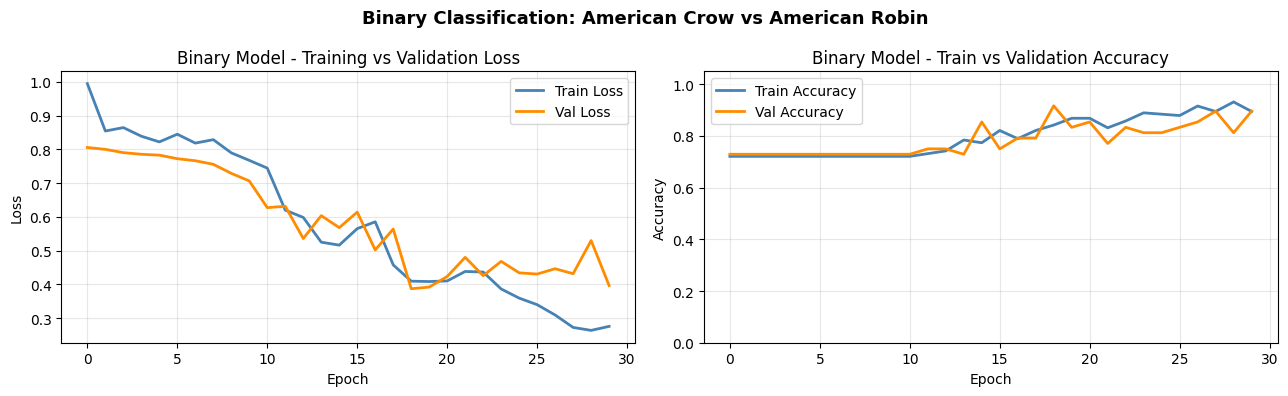

In [16]:
# Plot binary training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(bin_losses,     label='Train Loss', linewidth=2, color='steelblue')
axes[0].plot(bin_val_losses, label='Val Loss',   linewidth=2, color='darkorange')
axes[0].set_title('Binary Model - Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(bin_train_accs, label='Train Accuracy', linewidth=2, color='steelblue')
axes[1].plot(bin_val_accs,   label='Val Accuracy',   linewidth=2, color='darkorange')
axes[1].set_title('Binary Model - Train vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1.05])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Binary Classification: American Crow vs American Robin',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('binary_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Lets use higher learning rate of 0.01 to compare

In [17]:
# Higher LR of 0.01
print("Training Binary CNN - Higher LR (0.01)...")
bin_model_v2 = BinaryCNN()
start = time.time()
bin_losses_v2, bin_val_losses_v2, bin_val_accs_v2, bin_train_accs_v2 = train_binary(
    bin_model_v2, bin_train_loader, bin_test_loader,
    epochs=30, lr=0.01, pos_weight=pos_weight)
elapsed_v2 = time.time() - start
print(f"Complete in {elapsed_v2:.1f}s | Final Val Acc: {bin_val_accs_v2[-1]:.4f}\n")

Training Binary CNN - Higher LR (0.01)...
Epoch 5/30 | Train Loss: 0.8651 | Val Loss: 0.8163 | Train Acc: 0.7211 | Val Acc: 0.7292
Epoch 10/30 | Train Loss: 0.8845 | Val Loss: 0.8557 | Train Acc: 0.7211 | Val Acc: 0.7292
Epoch 15/30 | Train Loss: 0.8564 | Val Loss: 0.8295 | Train Acc: 0.7211 | Val Acc: 0.7292
Epoch 20/30 | Train Loss: 0.8470 | Val Loss: 0.8171 | Train Acc: 0.7211 | Val Acc: 0.7292
Epoch 25/30 | Train Loss: 0.8599 | Val Loss: 0.8185 | Train Acc: 0.7211 | Val Acc: 0.7292
Epoch 30/30 | Train Loss: 0.8677 | Val Loss: 0.8157 | Train Acc: 0.7211 | Val Acc: 0.7292
Complete in 454.9s | Final Val Acc: 0.7292



The higher learning rate did not perform better than the original model as the accuracy falls below 73%.

In [18]:
# Simpler architecture with learning rate 0.001
class BinaryCNN_Simple(nn.Module):
    def __init__(self):
        super(BinaryCNN_Simple, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((8, 8))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

print("Training Simple Binary CNN...")
bin_model_v3 = BinaryCNN_Simple()
start = time.time()
bin_losses_v3, bin_val_losses_v3, bin_val_accs_v3, bin_train_accs_v3 = train_binary(
    bin_model_v3, bin_train_loader, bin_test_loader,
    epochs=30, lr=0.001, pos_weight=pos_weight)
elapsed_v3 = time.time() - start
print(f"Complete in {elapsed_v3:.1f}s | Final Val Acc: {bin_val_accs_v3[-1]:.4f}\n")

Training Simple Binary CNN...
Epoch 5/30 | Train Loss: 0.8174 | Val Loss: 0.7757 | Train Acc: 0.7211 | Val Acc: 0.7292
Epoch 10/30 | Train Loss: 0.7510 | Val Loss: 0.7137 | Train Acc: 0.7211 | Val Acc: 0.7292
Epoch 15/30 | Train Loss: 0.6587 | Val Loss: 0.5890 | Train Acc: 0.7211 | Val Acc: 0.7292
Epoch 20/30 | Train Loss: 0.5134 | Val Loss: 0.4923 | Train Acc: 0.7211 | Val Acc: 0.7292
Epoch 25/30 | Train Loss: 0.5507 | Val Loss: 0.5588 | Train Acc: 0.7211 | Val Acc: 0.7292
Epoch 30/30 | Train Loss: 0.4331 | Val Loss: 0.4568 | Train Acc: 0.8158 | Val Acc: 0.8125
Complete in 135.2s | Final Val Acc: 0.8125



This one performed better than high lr but original model is best.

### Comparing Binary Models

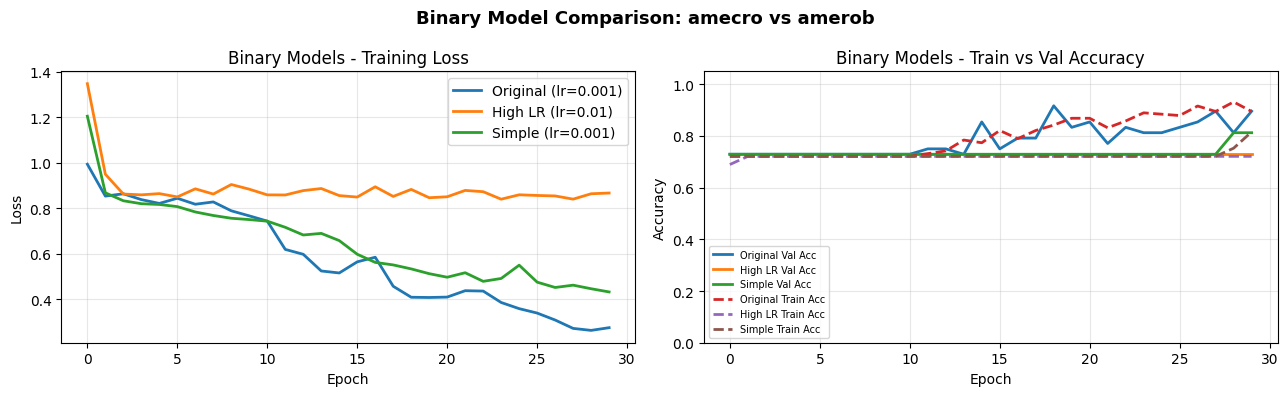

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(bin_losses,    label='Original (lr=0.001)', linewidth=2)
axes[0].plot(bin_losses_v2, label='High LR (lr=0.01)',   linewidth=2)
axes[0].plot(bin_losses_v3, label='Simple (lr=0.001)',   linewidth=2)
axes[0].set_title('Binary Models - Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(bin_val_accs,      label='Original Val Acc',  linewidth=2)
axes[1].plot(bin_val_accs_v2,   label='High LR Val Acc',   linewidth=2)
axes[1].plot(bin_val_accs_v3,   label='Simple Val Acc',    linewidth=2)
axes[1].plot(bin_train_accs,    label='Original Train Acc',linewidth=2, linestyle='--')
axes[1].plot(bin_train_accs_v2, label='High LR Train Acc', linewidth=2, linestyle='--')
axes[1].plot(bin_train_accs_v3, label='Simple Train Acc',  linewidth=2, linestyle='--')
axes[1].set_title('Binary Models - Train vs Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1.05])
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Binary Model Comparison: amecro vs amerob',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('binary_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Summary table
print("\n=== Binary Model Comparison ===")
print(f"{'Model':<25} {'Train Acc':>10} {'Val Acc':>10} {'Time':>8}")
print("-" * 57)
print(f"{'Original (lr=0.001)':<25} {bin_train_accs[-1]:>10.4f} "
      f"{bin_val_accs[-1]:>10.4f} {elapsed:>7.1f}s")
print(f"{'High LR (lr=0.01)':<25} {bin_train_accs_v2[-1]:>10.4f} "
      f"{bin_val_accs_v2[-1]:>10.4f} {elapsed_v2:>7.1f}s")
print(f"{'Simple (lr=0.001)':<25} {bin_train_accs_v3[-1]:>10.4f} "
      f"{bin_val_accs_v3[-1]:>10.4f} {elapsed_v3:>7.1f}s")


=== Binary Model Comparison ===
Model                      Train Acc    Val Acc     Time
---------------------------------------------------------
Original (lr=0.001)           0.8947     0.8958   432.2s
High LR (lr=0.01)             0.7211     0.7292   454.9s
Simple (lr=0.001)             0.8158     0.8125   135.2s


Among the three configurations, the original model with a learning rate of 0.001 and three convolutional layers produced the best overall results. It achieved 89% accuracy even though it took some time. These experiments show that choosing the right hyperparameters, especially the learning rate, plays a major role in CNN performance. They also demonstrate that having enough network depth is important for learning meaningful audio patterns from bird call spectrograms.

## Multiclass Classification: All 12 Species

After completing the binary classification task, the model is extended to classify all 12 bird species simultaneously. The output layer is modified to contain 12 neurons, and CrossEntropyLoss is used for multiclass learning.

Additional improvements are introduced to make training more stable and effective. Batch normalization layers are added after convolutional layers, and a learning rate scheduler is used to reduce the learning rate every 10 epochs.

Three different configurations are compared:
- the original CNN model,
- a deeper model with four convolutional layers,
- and a model trained with a smaller learning rate.

These experiments help evaluate whether increasing model complexity improves overall performance.

In [21]:
class MultiCNN(nn.Module):
    def __init__(self, num_classes=12):
        super(MultiCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((8, 8))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

In [ ]:
#Compute multiclass weights for balanced class
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.tensor(
    class_weights, dtype=torch.float32).to(device)

print("Class weights:")
for i, s in enumerate(species):
    print(f"  {s}: {class_weights[i]:.4f}")

# Updated multiclass training function
def train_multi(model, train_loader, test_loader, epochs=50, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=10, gamma=0.5)

    train_losses, val_losses, val_accs, train_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct_train, total_train = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            correct_train += (preds.argmax(dim=1) == yb).sum().item()
            total_train += yb.size(0)
        scheduler.step()
        train_acc = correct_train / total_train

        model.eval()
        correct, total = 0, 0
        val_loss = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_loss += loss.item()
                correct += (preds.argmax(dim=1) == yb).sum().item()
                total += yb.size(0)

        val_acc = correct / total
        train_losses.append(running_loss / len(train_loader))
        val_losses.append(val_loss / len(test_loader))
        val_accs.append(val_acc)
        train_accs.append(train_acc)

        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {train_losses[-1]:.4f} | "
                  f"Val Loss: {val_losses[-1]:.4f} | "
                  f"Train Acc: {train_acc:.4f} | "
                  f"Val Acc: {val_acc:.4f}")

    return train_losses, val_losses, val_accs, train_accs

# Train original multiclass model
print("\nTraining Multiclass CNN (balanced)...")
multi_model = MultiCNN()
start = time.time()
multi_losses, multi_val_losses, multi_val_accs, multi_train_accs = train_multi(
    multi_model, train_loader, test_loader, epochs=100)
elapsed_multi = time.time() - start
print(f"\nComplete in {elapsed_multi:.1f}s")
print(f"Final Train Acc: {multi_train_accs[-1]:.4f}")
print(f"Final Val Acc:   {multi_val_accs[-1]:.4f}")

Class weights:
  amecro: 2.4906
  amerob: 0.9635
  bewwre: 1.1478
  bkcchi: 3.6667
  daejun: 1.3200
  houfin: 1.9701
  houspa: 0.2619
  norfli: 4.4000
  rewbla: 0.8859
  sonspa: 0.6286
  spotow: 1.2000
  whcspa: 1.8082

Training Multiclass CNN (balanced)...
Epoch 5/100 | Train Loss: 2.1439 | Val Loss: 2.1622 | Train Acc: 0.2039 | Val Acc: 0.2116


Since it perfomed best at epoch 50, we will use that as our final mode;.

In [ ]:
# Final multiclass model - train to best epoch
print("Training Final Multiclass CNN (50 epochs)...")
multi_model = MultiCNN()
start = time.time()
multi_losses, multi_val_losses, multi_val_accs, multi_train_accs = train_multi(
    multi_model, train_loader, test_loader, epochs=50)
elapsed_multi = time.time() - start
print(f"\nComplete in {elapsed_multi:.1f}s")
print(f"Best Val Acc: {max(multi_val_accs):.4f} at epoch {np.argmax(multi_val_accs)+1}")
print(f"Final Val Acc: {multi_val_accs[-1]:.4f}")

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(multi_losses,     label='Train Loss', linewidth=2, color='steelblue')
axes[0].plot(multi_val_losses, label='Val Loss',   linewidth=2, color='darkorange')
axes[0].set_title('Multiclass Model - Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(multi_train_accs, label='Train Accuracy', linewidth=2, color='steelblue')
axes[1].plot(multi_val_accs,   label='Val Accuracy',   linewidth=2, color='darkorange')
axes[1].set_title('Multiclass Model - Train vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1.05])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Multiclass Classification - 12 Species',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('multiclass_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Training and validation loss and accuracy for the original multiclass model over 50 epochs. Both losses decrease in early epochs before the validation loss peaks around epoch 20 while training loss continues falling, indicating mild overfitting. Validation accuracy peaks at approximately 45% before stabilizing, reflecting the genuine difficulty of classifying 12 species with a heavily imbalanced dataset ranging from 37 to 630 samples per class.

In [ ]:
# Deep model
class MultiCNN_Deep(nn.Module):
    def __init__(self, num_classes=12):
        super(MultiCNN_Deep, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

print("Training Deep Multiclass CNN...")
multi_model_deep = MultiCNN_Deep()
start = time.time()
multi_losses_deep, multi_val_losses_deep, multi_val_accs_deep, multi_train_accs_deep = train_multi(
    multi_model_deep, train_loader, test_loader, epochs=50)
elapsed_deep = time.time() - start
print(f"Complete in {elapsed_deep:.1f}s | Best Val Acc: {max(multi_val_accs_deep):.4f}\n")


In [ ]:
#Low LR
print("Training Low LR Multiclass CNN...")
multi_model_v3 = MultiCNN()
start = time.time()
multi_losses_v3, multi_val_losses_v3, multi_val_accs_v3, multi_train_accs_v3 = train_multi(
    multi_model_v3, train_loader, test_loader, epochs=50, lr=0.0001)
elapsed_v3 = time.time() - start
print(f"Complete in {elapsed_v3:.1f}s | Best Val Acc: {max(multi_val_accs_v3):.4f}\n")

### Comparing Multiclass

In [ ]:
# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(multi_losses,      label='Original (lr=0.001)', linewidth=2)
axes[0].plot(multi_losses_deep, label='Deep (lr=0.001)',     linewidth=2)
axes[0].plot(multi_losses_v3,   label='Low LR (lr=0.0001)', linewidth=2)
axes[0].set_title('Multiclass Models - Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(multi_val_accs,      label='Original Val Acc',  linewidth=2)
axes[1].plot(multi_val_accs_deep, label='Deep Val Acc',      linewidth=2)
axes[1].plot(multi_val_accs_v3,   label='Low LR Val Acc',    linewidth=2)
axes[1].plot(multi_train_accs,      label='Original Train Acc', linewidth=2, linestyle='--')
axes[1].plot(multi_train_accs_deep, label='Deep Train Acc',     linewidth=2, linestyle='--')
axes[1].plot(multi_train_accs_v3,   label='Low LR Train Acc',   linewidth=2, linestyle='--')
axes[1].set_title('Multiclass Models - Train vs Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1.05])
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Multiclass Model Comparison (12 Species)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('multiclass_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Multiclass Model Comparison ===")
print(f"{'Model':<25} {'Best Val Acc':>12} {'Time':>8}")
print("-" * 48)
print(f"{'Original (lr=0.001)':<25} {max(multi_val_accs):>12.4f} {elapsed_multi:>7.1f}s")
print(f"{'Deep (lr=0.001)':<25} {max(multi_val_accs_deep):>12.4f} {elapsed_deep:>7.1f}s")
print(f"{'Low LR (lr=0.0001)':<25} {max(multi_val_accs_v3):>12.4f} {elapsed_v3:>7.1f}s")

The deeper four-layer model performed the best, achieving the lowest training loss and the highest validation accuracy of about 55%. In comparison, the original three-layer model and the low learning rate model both leveled off at around 40–45% validation accuracy. All three models showed a widening gap between training and validation accuracy after about 20 epochs, suggesting
that some overfitting occurred as training continued. The deep model reached roughly 60% training accuracy while maintaining about 55% validation accuracy, indicating better generalization than the other models despite its longer training time of 275 seconds. The low learning rate model
learned more slowly throughout the training process and did not provide any noticeable improvement over the original model.

### Confusion Matrix

In [ ]:
# Use the deep model as final model
multi_model = multi_model_deep

# Confusion Matrix
multi_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = multi_model(xb).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=species,
            yticklabels=species)
plt.title('Confusion Matrix - 12 Species Multiclass Model',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


House Sparrow (houspa) had the best results, with 92 correct predictions
out of 126 test images. This species also had the largest training dataset, with 630 samples. On the other hand, Northern Flicker (norfli) and Black-capped Chickadee (bkcchi) had the weakest performance, with only 1 and 2 correct predictions, respectively. These species had the smallest training datasets, containing only 37 and 45 samples. Some species were often confused with one
another. For example, Bewick's Wren (bewwre) was frequently predicted as Song Sparrow (sonspa),and Red-winged Blackbird (rewbla) was misclassified as House Sparrow (houspa) several times. Overall, the results suggest that species with more training data were classified more accurately, while species with fewer samples were much harder for the model to identify correctly

### Classification Report

In [ ]:
print("\n=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=species))

### Test Data Predictions

To evaluate the trained model on unseen recordings, three unlabeled MP3 clips are analyzed using a sliding-window approach. Each audio file is divided into overlapping 3-second windows with a stride of 1 second.

For every window, a mel spectrogram is generated, resized, normalized, and passed through the trained 12-class CNN model. The final prediction for each recording is determined using the most common prediction across all windows.

Probability distributions are also visualized to measure prediction confidence and to identify recordings that may contain multiple bird species.

In [ ]:
# Test MP3 Predictions
test_files = ['test1.mp3', 'test2.mp3', 'test3.mp3']
test_path  = '/content/drive/MyDrive/Homework3/test_birds/'

def mp3_to_spectrograms(path, sr=22050, duration=3, n_mels=128):
    y, sr = librosa.load(path, sr=sr)
    window_size = duration * sr
    hop_size = sr
    specs = []
    for start in range(0, len(y) - window_size, hop_size):
        clip = y[start:start + window_size]
        S = librosa.feature.melspectrogram(y=clip, sr=sr, n_mels=n_mels)
        S_db = librosa.power_to_db(S, ref=np.max)
        specs.append(S_db)
    return specs, y, sr

def preprocess_spec(spec, target_freq=128, target_time=130):
    img = Image.fromarray(spec.astype(np.float32))
    img_resized = img.resize((target_time, target_freq))
    arr = np.array(img_resized, dtype=np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    return arr

multi_model.eval()
results = {}

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for i, fname in enumerate(test_files):
    fpath = test_path + fname
    specs, y_audio, sr = mp3_to_spectrograms(fpath)

    print(f"\n{fname}: {len(specs)} windows extracted")

    window_preds = []
    window_probs = []

    for spec in specs:
        arr = preprocess_spec(spec)
        tensor = torch.tensor(arr, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = multi_model(tensor)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred   = np.argmax(probs)

        window_preds.append(pred)
        window_probs.append(probs)

    pred_counts  = Counter(window_preds)
    top_pred_idx = pred_counts.most_common(1)[0][0]
    top_species  = species[top_pred_idx]
    avg_probs    = np.mean(window_probs, axis=0)
    top3         = np.argsort(avg_probs)[::-1][:3]

    results[fname] = {
        'window_preds': window_preds,
        'avg_probs': avg_probs,
        'top_pred': top_species
    }

    print(f"Window predictions: {[species[p] for p in window_preds]}")
    print(f"Top prediction: {top_species}")
    print(f"Top 3 probabilities:")
    for idx in top3:
        print(f"  {species[idx]}: {avg_probs[idx]:.4f}")

    axes[i].bar(species, avg_probs, color='steelblue')
    axes[i].set_title(f'{fname} - Predicted: {top_species}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Avg Probability')
    axes[i].set_xticks(range(len(species)))
    axes[i].set_xticklabels(species, rotation=45, ha='right')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Test Bird Predictions - Probability Distribution per Clip',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved!")

In all cases, the model is not very confident, with the highest probabilities only 24%, 37%, and 27% for test1, test2, and test3. For test1.mp3, the model predicts House Finch (houfin) with 24%, but it also gives noticeable scores to House Sparrow (houspa), Red-winged Blackbird (rewbla), and Bewick's Wren (bewwre), meaning different species may be mixed across its 21 segments. For
test2.mp3, the top prediction is Red-winged Blackbird (rewbla) at 37%, but American Robin (amerob) and Northern Flicker (norfli) also get high scores, showing clear uncertainty. For test3.mp3, the model predicts Black-capped Chickadee (bkcchi) at 27%, but White-crowned Sparrow (whcspa) is close behind at about 20%, suggesting these two species may sound similar to
the model.

In [ ]:
#  Full spectrograms of test clips
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for i, fname in enumerate(test_files):
    fpath = test_path + fname
    y_audio, sr = librosa.load(fpath, sr=22050)

    S = librosa.feature.melspectrogram(y=y_audio, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)

    img = axes[i].imshow(S_db, aspect='auto', origin='lower', cmap='magma')
    axes[i].set_title(
        f'{fname} - Predicted: {results[fname]["top_pred"]} '
        f'(confidence: {results[fname]["avg_probs"].max():.2%})',
        fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Time Frame')
    axes[i].set_ylabel('Mel Frequency Bin')
    plt.colorbar(img, ax=axes[i], label='dB')

plt.suptitle('Full Spectrograms of Test Bird Clips',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('test_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()


The mel spectrograms for the three test audio clips, which basically visualize how sound energy changes over time and frequency.test1.mp3 is the longest clip (about 1000 frames) and shows steady low-frequency sound with several sharp bursts of higher-frequency activity. This suggests there are multiple call events, and possibly more than one bird species in the recording. test2.mp3 is much shorter (around 220 frames) and has a clear repeating curved pattern in the mid-frequency range (about 40-80 mel bins), which looks like a single bird making a consistent type of call. test3.mp3 shows four separate groups of high-frequency activity above mel bin 100, with quiet gaps in between, which looks like short repeated calls from a small songbird. Overall, each recording has a very different pattern, which matches the differences in prediction confidence seen earlier and shows that the clips contain clearly different types of bird sounds.

## Hyperparameter Tuning

In [ ]:
# --- Hyperparameter Tuning Summary ---
print("=" * 65)
print("HYPERPARAMETER TUNING SUMMARY")
print("=" * 65)

print("\nBINARY MODEL TUNING")
print(f"{'Config':<30} {'LR':>8} {'Layers':>8} {'Val Acc':>10} {'Time':>8}")
print("-" * 65)
print(f"{'Original CNN':<30} {'0.001':>8} {'3':>8} {max(bin_val_accs):>10.4f} {elapsed:>7.1f}s")
print(f"{'High LR CNN':<30} {'0.01':>8} {'3':>8} {max(bin_val_accs_v2):>10.4f} {elapsed_v2:>7.1f}s")
print(f"{'Simple CNN':<30} {'0.001':>8} {'2':>8} {max(bin_val_accs_v3):>10.4f} {elapsed_v3:>7.1f}s")
print(f"\nSelected: Original CNN (lr=0.001)")
print(f"Reason: Best validation accuracy with reasonable training time")

print("\nMULTICLASS MODEL TUNING")
print(f"{'Config':<30} {'LR':>8} {'Layers':>8} {'Val Acc':>10} {'Time':>8}")
print("-" * 65)
print(f"{'Original CNN':<30} {'0.001':>8} {'3':>8} {max(multi_val_accs):>10.4f} {elapsed_multi:>7.1f}s")
print(f"{'Deep CNN':<30} {'0.001':>8} {'4':>8} {max(multi_val_accs_deep):>10.4f} {elapsed_deep:>7.1f}s")
print(f"{'Low LR CNN':<30} {'0.0001':>8} {'3':>8} {max(multi_val_accs_v3):>10.4f} {elapsed_v3:>7.1f}s")
print(f"\nSelected: Deep CNN (lr=0.001)")
print(f"Reason: Highest validation accuracy at {max(multi_val_accs_deep):.4f}")

print("\nKEY FINDINGS FROM TUNING:")
print("1. Learning rate has most impact — lr=0.01 caused failure in binary task")
print("2. Deeper architecture improved multiclass performance by ~10%")
print("3. Lower learning rate (0.0001) converged too slowly with no benefit")
print("4. Class weighting essential — without it model biased toward houspa")
print("5. Dataset imbalance (37-630 samples) is the main limiting factor")